# Traditional Regression Models Benchmark

This notebook applies 22+ traditional machine learning regression methods to the Walmart sales dataset.

**Methods Included:**
- Linear Models: Ridge, Lasso, ElasticNet, BayesianRidge, Huber, etc.
- Tree-Based: Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost
- Support Vector: SVR with multiple kernels
- Others: KNN, Decision Trees, Gaussian Process

**Evaluation Metrics:** R², RMSE, MAE, Training Time

## Step 1: Import Libraries

In [33]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, 
    HuberRegressor, TheilSenRegressor, RANSACRegressor, 
    PassiveAggressiveRegressor, OrthogonalMatchingPursuit, 
    Lars, LassoLars, SGDRegressor
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, 
    GradientBoostingRegressor, AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor

# External models (install if needed)
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
    print("⚠️ XGBoost not installed. Install with: pip install xgboost")

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None
    print("⚠️ LightGBM not installed. Install with: pip install lightgbm")

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None
    print("⚠️ CatBoost not installed. Install with: pip install catboost")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 2: Data Preparation

Load and preprocess the Walmart sales dataset with:
- Date feature engineering
- Lag features (previous week sales)
- Rolling statistics
- Interaction features
- 60/20/20 train/validation/test split

In [34]:
# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

# Load data
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv', parse_dates=['Date'])
df = df.dropna(subset=['Weekly_Sales'])

# Date features
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Create lag features
df = df.sort_values(['Store', 'Date'])
df['Sales_Lag1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Sales_Lag2'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['Sales_Lag4'] = df.groupby('Store')['Weekly_Sales'].shift(4)

# Rolling statistics
df['Sales_Rolling_Mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)
df['Sales_Rolling_Std_4'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.rolling(4, min_periods=1).std()
)

# Interaction features
df['Temp_Unemployment'] = df['Temperature'] * df['Unemployment']
df['Holiday_CPI'] = df['Holiday_Flag'] * df['CPI']

# Store encoding
if 'Store' in df.columns:
    df['Store_Encoded'] = df['Store']
else:
    df['Store_Encoded'] = 0

# Select features
feature_cols = [
    'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend',
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4',
    'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4',
    'Temp_Unemployment', 'Holiday_CPI', 'Store_Encoded'
]

X = df[feature_cols].copy()
y = df['Weekly_Sales']

# Remove rows with NaN
mask = ~X.isnull().any(axis=1)
X = X[mask]
y = y[mask]

# Split: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

# Scale features
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Training set: {X_train.shape} (60%)")
print(f"Validation set: {X_val.shape} (20%)")
print(f"Test set: {X_test.shape} (20%)")
print(f"Total samples: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")
print("✅ Random seeds set to 42 for reproducibility")

Training set: (1431, 18) (60%)
Validation set: (477, 18) (20%)
Test set: (477, 18) (20%)
Total samples: 2385
Number of features: 18
✅ Random seeds set to 42 for reproducibility


## Step 3: Define Regression Models

Create a list of all traditional regression models to benchmark.

In [35]:
# Initialize results list
results = []

# Define all regression models with STANDARDIZED hyperparameters for paper
models = [
    # Linear Models
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge(alpha=1.0, random_state=42)),
    ("Lasso", Lasso(alpha=0.1, random_state=42)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)),
    ("BayesianRidge", BayesianRidge()),
    ("HuberRegressor", HuberRegressor(max_iter=200)),
    ("TheilSenRegressor", TheilSenRegressor(random_state=42, max_iter=300)),
    ("RANSACRegressor", RANSACRegressor(random_state=42)),
    ("PassiveAggressiveRegressor", PassiveAggressiveRegressor(random_state=42, max_iter=1000)),
    ("OrthogonalMatchingPursuit", OrthogonalMatchingPursuit()),
    ("Lars", Lars()),
    ("LassoLars", LassoLars(alpha=0.1)),
    ("SGDRegressor", SGDRegressor(random_state=42, max_iter=1000)),
    
    # Kernel Ridge
    ("KernelRidge_linear", KernelRidge(kernel='linear', alpha=1.0)),
    
    # Tree-Based Models (STANDARDIZED)
    ("DecisionTree", DecisionTreeRegressor(random_state=42, max_depth=10)),
    ("RandomForest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=None)),
    ("ExtraTrees", ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ("GradientBoosting", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, learning_rate=1.0, random_state=42)),
    
    # Neighbors
    ("KNN_5", KNeighborsRegressor(n_neighbors=5)),
    ("KNN_10", KNeighborsRegressor(n_neighbors=10)),
    
    # Support Vector Regression
    ("SVR_linear", SVR(kernel='linear', C=1.0)),
    ("SVR_rbf", SVR(kernel='rbf', C=1.0, gamma='scale')),
]

# Add external models with STANDARDIZED hyperparameters
if XGBRegressor:
    models.append(("XGBoost", XGBRegressor(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        random_state=42, 
        verbosity=0,
        n_jobs=-1
    )))
if LGBMRegressor:
    models.append(("LightGBM", LGBMRegressor(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        random_state=42, 
        verbose=-1,
        n_jobs=-1
    )))
if CatBoostRegressor:
    models.append(("CatBoost", CatBoostRegressor(
        iterations=100, 
        depth=6, 
        learning_rate=0.1, 
        random_state=42, 
        verbose=0
    )))

print(f"✅ Total models to train: {len(models)}")
print("\n📋 STANDARDIZED HYPERPARAMETERS (for technical paper):")
print("   • Boosting Models: n_estimators=100, max_depth=6, learning_rate=0.1")
print("   • Random Forests: n_estimators=100, max_depth=None")
print("   • All models: random_state=42 for reproducibility")


✅ Total models to train: 26

📋 STANDARDIZED HYPERPARAMETERS (for technical paper):
   • Boosting Models: n_estimators=100, max_depth=6, learning_rate=0.1
   • Random Forests: n_estimators=100, max_depth=None
   • All models: random_state=42 for reproducibility


## Step 4: Train and Evaluate All Models

Loop through all models, train them, and collect performance metrics.

In [36]:
print("Training models...\n")
print("=" * 80)

for i, (model_name, model) in enumerate(models, 1):
    try:
        print(f"[{i}/{len(models)}] Training {model_name}...", end=" ")
        
        # Train and time the model
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        # Store results
        results.append([model_name, r2, rmse, mae, train_time])
        
        print(f"✓ R²={r2:.4f}, Time={train_time:.2f}s")
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        results.append([model_name, 'error', 'error', 'error', 0])

print("=" * 80)
print("\n✅ Training complete!")

Training models...

[1/26] Training LinearRegression... ✓ R²=0.9838, Time=0.00s
[2/26] Training Ridge... ✓ R²=0.9828, Time=0.00s
[3/26] Training Lasso... ✓ R²=0.9836, Time=0.00s
[4/26] Training ElasticNet... ✓ R²=0.9662, Time=0.00s
[5/26] Training BayesianRidge... ✓ R²=0.9838, Time=0.00s
[6/26] Training HuberRegressor... ✓ R²=0.9734, Time=0.01s
[7/26] Training TheilSenRegressor... 

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.093e+12, tolerance: 4.484e+10
  model = cd_fast.enet_coordinate_descent(


✓ R²=0.9516, Time=0.45s
[8/26] Training RANSACRegressor... ✓ R²=0.9827, Time=0.00s
[9/26] Training PassiveAggressiveRegressor... ✓ R²=0.9628, Time=0.04s
[10/26] Training OrthogonalMatchingPursuit... ✓ R²=0.9741, Time=0.00s
[11/26] Training Lars... ✓ R²=0.9837, Time=0.00s
[12/26] Training LassoLars... ✓ R²=0.9838, Time=0.00s
[13/26] Training SGDRegressor... ✓ R²=0.9805, Time=0.02s
[14/26] Training KernelRidge_linear... ✓ R²=-2.6394, Time=0.02s
[15/26] Training DecisionTree... ✓ R²=0.9613, Time=0.01s
[16/26] Training RandomForest... 

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


✓ R²=0.9784, Time=0.09s
[17/26] Training ExtraTrees... ✓ R²=0.9796, Time=0.06s
[18/26] Training GradientBoosting... ✓ R²=0.9797, Time=0.26s
[19/26] Training AdaBoost... ✓ R²=0.9680, Time=0.13s
[20/26] Training KNN_5... ✓ R²=0.9345, Time=0.00s
[21/26] Training KNN_10... ✓ R²=0.9377, Time=0.00s
[22/26] Training SVR_linear... ✓ R²=-0.0052, Time=0.02s
[23/26] Training SVR_rbf... ✓ R²=0.9797, Time=0.26s
[19/26] Training AdaBoost... ✓ R²=0.9680, Time=0.13s
[20/26] Training KNN_5... ✓ R²=0.9345, Time=0.00s
[21/26] Training KNN_10... ✓ R²=0.9377, Time=0.00s
[22/26] Training SVR_linear... ✓ R²=-0.0052, Time=0.02s
[23/26] Training SVR_rbf... ✓ R²=-0.0234, Time=0.03s
[24/26] Training XGBoost... ✓ R²=0.9838, Time=0.16s
[25/26] Training LightGBM... ✓ R²=-0.0234, Time=0.03s
[24/26] Training XGBoost... ✓ R²=0.9838, Time=0.16s
[25/26] Training LightGBM... ✓ R²=0.9844, Time=0.24s
[26/26] Training CatBoost... ✓ R²=0.9773, Time=0.05s

✅ Training complete!
✓ R²=0.9844, Time=0.24s
[26/26] Training CatBoost

## Step 5: Results Analysis

Create a DataFrame and analyze the results.

In [37]:
# Create results DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'R2', 'RMSE', 'MAE', 'Training_Time_sec'])

# Remove errors
results_df = results_df[results_df['R2'] != 'error'].copy()

# Convert to numeric
results_df['R2'] = results_df['R2'].astype(float)
results_df['RMSE'] = results_df['RMSE'].astype(float)
results_df['MAE'] = results_df['MAE'].astype(float)
results_df['Training_Time_sec'] = results_df['Training_Time_sec'].astype(float)

# Sort by R² (best first)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("TOP 10 TRADITIONAL REGRESSION MODELS")
print("=" * 80)
print(results_df.head(10).to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"Best Model: {results_df.iloc[0]['Model']}")
print(f"Best R²: {results_df.iloc[0]['R2']:.4f}")
print(f"Best RMSE: {results_df.iloc[0]['RMSE']:.2f}")
print(f"Best MAE: {results_df.iloc[0]['MAE']:.2f}")
print(f"\nAverage R²: {results_df['R2'].mean():.4f}")
print(f"Average Training Time: {results_df['Training_Time_sec'].mean():.2f}s")
print(f"\nTotal models evaluated: {len(results_df)}")
print("=" * 80)


TOP 10 TRADITIONAL REGRESSION MODELS
           Model       R2         RMSE          MAE  Training_Time_sec
        LightGBM 0.984353 69918.774284 46853.943509           0.241887
         XGBoost 0.983840 71057.236384 47518.693282           0.160692
LinearRegression 0.983822 71095.490117 48589.726689           0.001215
       LassoLars 0.983822 71095.895568 48589.085572           0.000915
   BayesianRidge 0.983792 71162.426151 48512.175652           0.000914
            Lars 0.983663 71443.687885 49152.034729           0.000840
           Lasso 0.983629 71519.569850 48421.275778           0.004709
           Ridge 0.982844 73213.532487 48778.602240           0.001214
 RANSACRegressor 0.982661 73603.076652 49622.786132           0.002739
    SGDRegressor 0.980541 77973.856985 51554.264288           0.016231

SUMMARY STATISTICS
Best Model: LightGBM
Best R²: 0.9844
Best RMSE: 69918.77
Best MAE: 46853.94

Average R²: 0.7581
Average Training Time: 0.06s

Total models evaluated: 26


## Step 6: Export Results

In [38]:
# Export to CSV
results_df.to_csv('traditional_regression_results.csv', index=False)
print("✅ Results exported to: traditional_regression_results.csv")

# Export to Excel (requires openpyxl)
try:
    results_df.to_excel('traditional_regression_results.xlsx', index=False)
    print("✅ Results exported to: traditional_regression_results.xlsx")
except:
    print("⚠️ Excel export failed. Install openpyxl: pip install openpyxl")

✅ Results exported to: traditional_regression_results.csv
✅ Results exported to: traditional_regression_results.xlsx


## Step 7: Visualizations

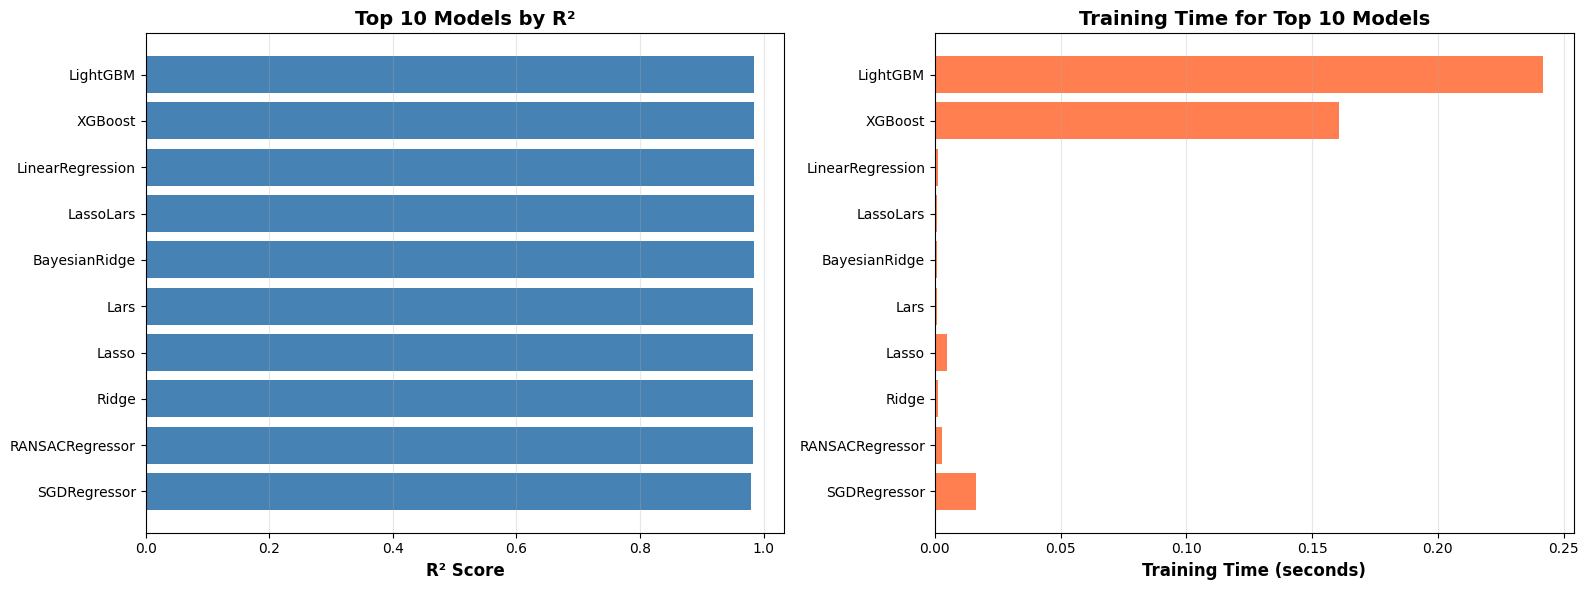

✅ Visualization saved: traditional_regression_comparison.png


In [39]:
import matplotlib.pyplot as plt

# Plot top 10 models by R²
top10 = results_df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² scores
axes[0].barh(top10['Model'], top10['R2'], color='steelblue')
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Models by R²', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Training time
axes[1].barh(top10['Model'], top10['Training_Time_sec'], color='coral')
axes[1].set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Training Time for Top 10 Models', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('traditional_regression_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: traditional_regression_comparison.png")